In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.image import imread
from tqdm.notebook import tqdm
import numpy as np
import torch
from collections import Counter

plt.rcParams['font.family'] = 'AppleGothic'
mpl.rcParams['font.family'] = 'AppleGothic'
classes = os.listdir('./data/data')
classes


Init Plugin
Init Graph Optimizer
Init Kernel


['input_69_2_7.jpg',
 'input_11_7_12.jpg',
 'input_81_4_10.jpg',
 'input_84_6_1.jpg',
 'input_36_3_3.jpg',
 'input_38_7_15.jpg',
 'input_3_1_15.jpg',
 'input_75_2_13.jpg',
 'input_17_8_2.jpg',
 'input_61_4_7.jpg',
 'input_95_4_6.jpg',
 'input_5_10_6.jpg',
 'input_97_6_13.jpg',
 'input_27_1_4.jpg',
 'input_91_10_9.jpg',
 'input_48_9_6.jpg',
 'input_2_1_15.jpg',
 'input_74_2_13.jpg',
 'input_26_3_3.jpg',
 'input_39_7_15.jpg',
 'input_79_2_7.jpg',
 'input_10_7_12.jpg',
 'input_94_6_1.jpg',
 'input_80_4_10.jpg',
 'input_96_6_13.jpg',
 'input_58_9_6.jpg',
 'input_90_10_9.jpg',
 'input_37_1_4.jpg',
 'input_4_10_6.jpg',
 'input_71_4_7.jpg',
 'input_85_4_6.jpg',
 'input_5_5_14.jpg',
 'input_73_6_12.jpg',
 'input_47_4_5.jpg',
 'input_33_5_8.jpg',
 'input_75_10_8.jpg',
 'input_17_3_13.jpg',
 'input_18_5_1.jpg',
 'input_39_9_10.jpg',
 'input_56_6_2.jpg',
 'input_91_2_12.jpg',
 'input_10_3_1.jpg',
 'input_65_4_11.jpg',
 'input_6_1_1.jpg',
 'input_16_3_13.jpg',
 'input_11_1_6.jpg',
 'input_7_3_6.jp

In [2]:
labels = pd.read_csv('./chinese_mnist.csv')
labels

,suite_id,sample_id,code,value,character
0,1,1,10,9,九
1,1,10,10,9,九
2,1,2,10,9,九
3,1,3,10,9,九
4,1,4,10,9,九
...,...,...,...,...,...
14995,99,5,9,8,八
14996,99,6,9,8,八
14997,99,7,9,8,八
14998,99,8,9,8,八


In [3]:
a=labels['suite_id'].unique()#봉사자 고유인원
a.sort()
print(a ,len(a))

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100] 100


In [4]:
b=labels['sample_id'].unique()#봉사자가 15개의 한자를 10번적음
b.sort()
print(b ,len(b))

[ 1  2  3  4  5  6  7  8  9 10] 10


In [5]:
c=labels['character'].unique()#한자
print(c ,len(c))

['九' '十' '百' '千' '万' '亿' '零' '一' '二' '三' '四' '五' '六' '七' '八'] 15


In [6]:
d=labels['value'].unique()#한자의 뜻
print(d ,len(d))

[        9        10       100      1000     10000 100000000         0
         1         2         3         4         5         6         7
         8] 15


In [7]:
e=labels['code'].unique()#한자 인덱스? 한자0 = 1, 한자10000 = 14
print(e ,len(e))

[10 11 12 13 14 15  1  2  3  4  5  6  7  8  9] 15


In [8]:
an = ['零', '一', '二', '三', '四', '五', '六', '七', '八', '九', '十', '百', '千', '万', '亿']
an

['零', '一', '二', '三', '四', '五', '六', '七', '八', '九', '十', '百', '千', '万', '亿']

In [9]:
# 데이터프레임에 파일 컬럼 추가하고 값입력
def cfn(x):
    file_name = f"input_{x[0]}_{x[1]}_{x[2]}.jpg"
    return file_name

labels['file'] = labels.apply(cfn,axis = 1)
labels

,suite_id,sample_id,code,value,character,file
0,1,1,10,9,九,input_1_1_10.jpg
1,1,10,10,9,九,input_1_10_10.jpg
2,1,2,10,9,九,input_1_2_10.jpg
3,1,3,10,9,九,input_1_3_10.jpg
4,1,4,10,9,九,input_1_4_10.jpg
...,...,...,...,...,...,...
14995,99,5,9,8,八,input_99_5_9.jpg
14996,99,6,9,8,八,input_99_6_9.jpg
14997,99,7,9,8,八,input_99_7_9.jpg
14998,99,8,9,8,八,input_99_8_9.jpg


In [10]:
labels.groupby(['value','character']).size()# 개수확인

value      character
0          零            1000
1          一            1000
2          二            1000
3          三            1000
4          四            1000
5          五            1000
6          六            1000
7          七            1000
8          八            1000
9          九            1000
10         十            1000
100        百            1000
1000       千            1000
10000      万            1000
100000000  亿            1000
dtype: int64

In [11]:
labels.isnull().sum()#NaN개수 확인

suite_id     0
sample_id    0
code         0
value        0
character    0
file         0
dtype: int64

In [12]:
import cv2
dataset=[]
data_location = './data/data'
for i in tqdm(range(len(labels))):
    codei = labels.loc[i,'code']
    filei = labels.loc[i,'file']
    path = os.path.join(data_location,filei)
    image = cv2.imread(path)
    image = image.astype(np.float32)
    image = torch.from_numpy(image)
    image = image.permute(2,1,0)
    dataset += [[image,codei-1]]


  0%|          | 0/15000 [00:00<?, ?it/s]

In [13]:
dataset[0][0].shape

torch.Size([3, 64, 64])

In [14]:
dataset[0]

[tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 9]

In [15]:
from sklearn.model_selection import train_test_split

idx_label = {}

for i in range(len(dataset)):
    _, label = dataset[i]
    idx_label[i] = label
x_train, x_val, y_train, y_val = train_test_split(list(idx_label.keys()), list(idx_label.values()), 
                                                  stratify = list(idx_label.values()), test_size=0.05)

idx_label_2 = {}
for idx, label in idx_label.items():
    if idx not in x_val:
        idx_label_2[idx] = label

#split data train and test after exlude x_val
x_train, x_test, y_train, y_test = train_test_split(list(idx_label_2.keys()), list(idx_label_2.values()),
                                                    stratify = list(idx_label_2.values()), test_size=0.05)


print(len(x_train))
print(len(x_val))
print(len(x_test))

13537
750
713


In [16]:
from torch.utils.data import DataLoader, SubsetRandomSampler
    
train_set = SubsetRandomSampler(x_train)
val_set = SubsetRandomSampler(x_val)
test_set = SubsetRandomSampler(x_test)

train_loader = DataLoader(dataset, batch_size=64, 
                          num_workers=4, sampler= train_set)
val_loader = DataLoader(dataset, batch_size=64,  
                        num_workers=4, sampler=val_set)
test_loader = DataLoader(dataset, batch_size = 64,
                          num_workers=4, sampler=test_set)

In [17]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
import time


model = models.resnet34(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 15)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)


In [19]:
num_epochs = 4
start_time = time.time()

for epoch in range(num_epochs):

    print('Epoch:', str(epoch+1) + '/' + str(num_epochs))

    for phase in ['train', 'val']:

        running_loss = 0.
        running_corrects = 0
        
        if phase == 'train':

            model.train()

            for inputs, labels in train_loader:

                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()
                outputs = model(inputs)

                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(train_set)
            epoch_acc = running_corrects / len(train_set) * 100.

            print(phase,'|' , ' Loss: {:.4f}  / Train Acc: {:.4f}%'.format(epoch_loss,epoch_acc))

        if phase == 'val':

            model.eval()

            for inputs, labels in val_loader:

                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(val_set)
            epoch_acc = running_corrects / len(val_set) * 100.

            print(phase ,'|', ' Loss: {:.4f}  / Acc: {:.4f}%'.format(epoch_loss,epoch_acc))

    print('Time:'+ str(int(time.time() - start_time)//60)+'분'+str(int(time.time() - start_time)%60)+'초')
    print('-'*10)


Epoch: 1/4
train |  Loss: 0.4673  / Train Acc: 86.8361%
val |  Loss: 0.0698  / Acc: 97.0667%
Time:13분9초
----------
Epoch: 2/4
train |  Loss: 0.0428  / Train Acc: 98.8550%
val |  Loss: 0.0375  / Acc: 98.6667%
Time:24분59초
----------
Epoch: 3/4
train |  Loss: 0.0208  / Train Acc: 99.4977%
val |  Loss: 0.0464  / Acc: 98.9333%
Time:34분9초
----------
Epoch: 4/4
train |  Loss: 0.0193  / Train Acc: 99.4681%
val |  Loss: 0.0245  / Acc: 99.0667%
Time:43분11초
----------


In [23]:
torch.save(model, 'resnet34_no_lung.pt')

In [24]:
def showtime(input):
    input = input.permute(2,1,0)
    input = input.numpy().astype(int)

    plt.imshow(input)
    plt.show()

[예측 결과: 四] (실제 정답: 四)


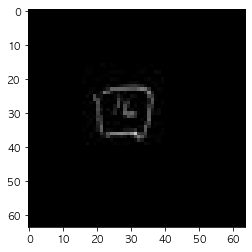

[예측 결과: 四] (실제 정답: 四)


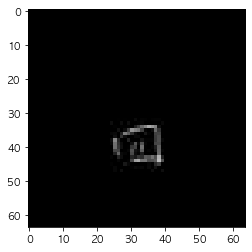

[예측 결과: 五] (실제 정답: 五)


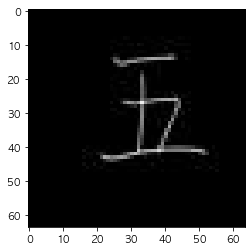

[예측 결과: 八] (실제 정답: 八)


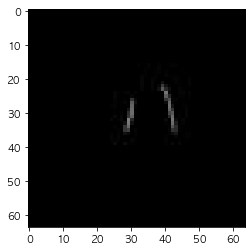

[예측 결과: 万] (실제 정답: 万)


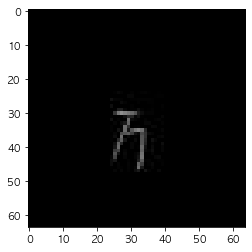

[예측 결과: 亿] (실제 정답: 亿)


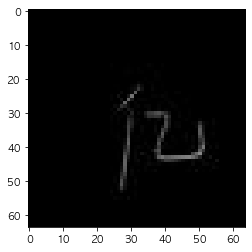

[예측 결과: 二] (실제 정답: 二)


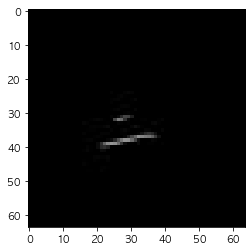

[예측 결과: 零] (실제 정답: 零)


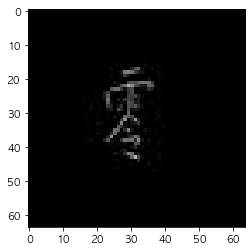

[예측 결과: 五] (실제 정답: 五)


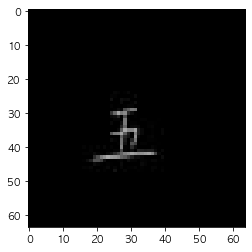

[예측 결과: 万] (실제 정답: 万)


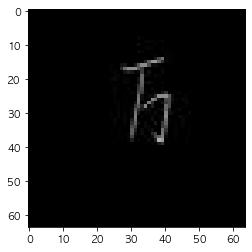

[예측 결과: 一] (실제 정답: 一)


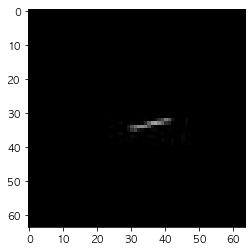

[예측 결과: 亿] (실제 정답: 亿)


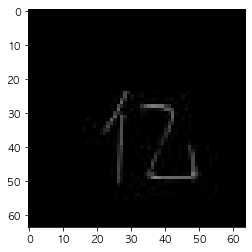

[Test Phase] Loss: 0.0159 Acc: 99.4390% Time: 11.4875s


In [25]:

model = torch.load('resnet34_no_lung.pt')
model.eval()
start_time = time.time()

with torch.no_grad():
    running_loss = 0.
    running_corrects = 0

    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

        print(f'[예측 결과: {an[preds[0]]}] (실제 정답: {an[labels.data[0]]})')
        showtime(inputs.cpu().data[0])

    epoch_loss = running_loss / len(test_set)
    epoch_acc = running_corrects / len(test_set) * 100.
    print('[Test Phase] Loss: {:.4f} Acc: {:.4f}% Time: {:.4f}s'.format(epoch_loss, epoch_acc, time.time() - start_time))